# 看懂一次LACT恒星强度干涉观测

先看理论信号，再跟踪同一场景如何变成光电子、单镜波形、两镜相关和UV测量。
最后改变模型与参数，查看角直径、探索性图像和性能。
基准场景始终是**AB星等2、直径0.16 mas的均匀圆盘、400±1 nm、36镜、6小时**。
小节另有变化时会明确列出，不用放大注入冒充物理观测。

本Notebook负责展示过程；详细定义、完整推导和实现对应见[物理说明](../docs/SII_PHYSICS_ZH.md)，
运行及数据接口见[实现说明](../docs/SII_IMPLEMENTATION_ZH.md)。末尾附加验证会实际重算，
它们不必打断第一次阅读主线。


In [1]:
from pathlib import Path
import os, sys, json, platform, hashlib
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from dataclasses import replace
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT/'python').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT/'python'))
import sii_unified as sii
import sii_reconstruction as reco
from sii_layout import read_corsika_layout
from sii_validation import (verify_main_parameters, analytic_waveform_calibration,
    thermal_mode_counts, waveform_records, standard_deviation_interval, proportion_interval,
    profile_model_grid, profile_grid_interval)
FIG = ROOT/'docs/sii_science_figures'
OUT = ROOT/'validation/sii_science'
FIG.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
SEED = 20260905
plt.rcParams.update({'figure.dpi':110, 'savefig.dpi':180, 'axes.grid':True, 'grid.alpha':.2})
summary = {'seed':SEED, 'python':platform.python_version(), 'numpy':np.__version__, 'scipy':scipy.__version__}
summary['code_sha256_lf']={path:hashlib.sha256((ROOT/path).read_bytes().replace(b'\r\n',b'\n')).hexdigest()
    for path in ['python/sii_unified.py','python/sii_reconstruction.py','python/sii_validation.py',
                 'python/sii_observation.py','python/sii_layout.py','python/sii_performance.py','tools/validate_sii_observation.py',
                 'tools/validate_sii_tracking.py',
                 'tools/validate_sii_performance.py',
                 'python/sii_walkthrough.py',
                 'tools/build_sii_science_notebook.py']}
manifest = verify_main_parameters(ROOT)
summary['main_parameter_commit'] = manifest['main_commit']
instrument = sii.Instrument.from_repository(ROOT)
observation = sii.Observation(hours_per_night=6., segment_s=1200, visibility_subsamples_per_segment=9)
layout = read_corsika_layout(ROOT/'configs/arrays/lact36_20260906.input')
summary['derived_input_sha256_lf']={path:hashlib.sha256((ROOT/path).read_bytes().replace(b'\r\n',b'\n')).hexdigest()
    for path in ['configs/arrays/lact36_20260906.input',
                 'configs/arrays/lact36_20260906_coordinates.csv',
                 'configs/optics/lact2_measured_single_pixel_400nm.csv',
                 'configs/optics/lact2_measured_single_pixel_400nm.provenance.json']}
unknown = ['microcell_recovery_time_ns','intrinsic_time_jitter_ns','electronic_noise_rms_mv',
           'sipm_crosstalk_probability','sipm_afterpulse_probability','dark_count_rate_hz','adc_bits']
assert all(getattr(instrument, name) == 0 for name in unknown)
summary['missing_effects_disabled'] = {name:getattr(instrument,name) for name in unknown}
display(pd.DataFrame(manifest['files'])[['path','matches_main']])
import sii_walkthrough as walk
from dataclasses import asdict
baseline_source=sii.BinarySource(ab_magnitude=2.,primary_diameter_mas=.16)

,path,matches_main
0,configs/electronics/measured_spe_4ns.cfg,True
1,configs/electronics/parameters/spe_template_me...,True
2,configs/electronics/parameters/spe_charge_samp...,True
3,configs/electronics/devices/s17351_tiled_2x4.cfg,True
4,configs/efficiency/mirror_reflectivity_dm0113_...,True
5,configs/efficiency/filter_transmission.csv,True
6,configs/efficiency/sipm_pde.csv,True
7,configs/nsb/nsb_spectrum.csv,True
8,configs/calibrated/lact2_measured_20260622/mir...,True
9,configs/calibrated/lact2_measured_20260622/mir...,True


## 1. 先知道我们在寻找什么信号

同一颗圆盘星有三种不同表示：天空中的亮度分布、随投影基线改变的可见度、
理想光子到达的时间相关。我们测量的是平方可见度P；它可以有零点和旁瓣。
第三幅图的相关峰处在皮秒尺度，**不是4 ns采样ADC直接看到的峰**。
Tel.1与Tel.2选自原始36镜input，在时角H=0.5 rad（过中天后约1.90小时）作单对示例。


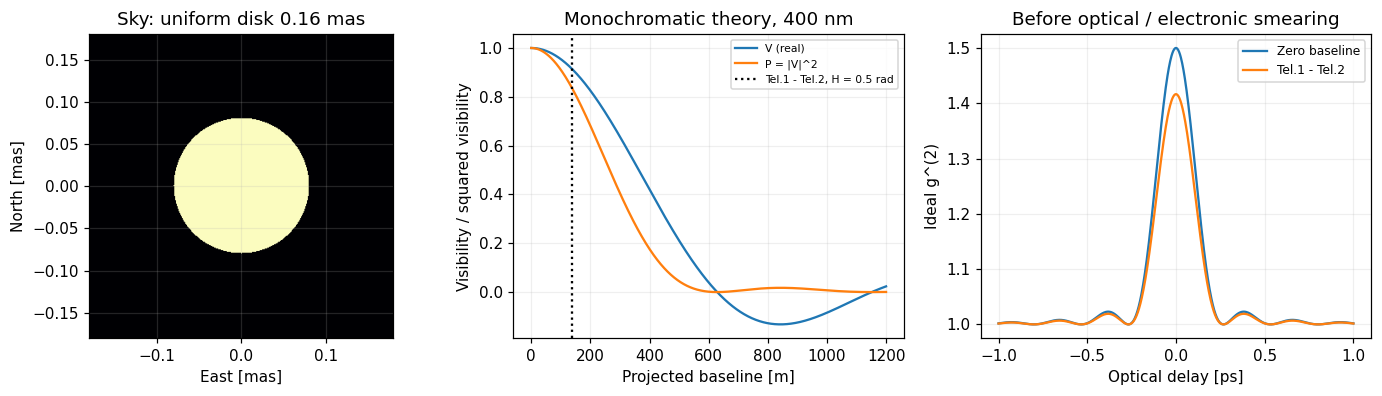

,基准值
source_case,single_disk
diameter_mas,0.16
magnitude,2.0
wavelength_nm,400.0
width_nm,2.0
source_dec_deg,22.0
site_lat_deg,29.36
telescopes,36
pair,"[1, 2]"
hour_angle_rad,0.5


In [2]:
lesson_scene=walk.theoretical_scene(ROOT,instrument,observation,layout,baseline_source,FIG,OUT)
summary['walkthrough']=lesson_scene['parameters']
display(pd.DataFrame([lesson_scene['parameters']]).T.rename(columns={0:'基准值'}))

## 2. 同一束光经过怎样的仪器响应

星等和通带决定探测光子率；光学路径差展宽到达时刻；每个光电子产生一份实测SPE。
下图先展示这些输入，再把它们用于下一节同一条真实随机记录。
光学核来自仓库光追缓存，SPE及电荷样本来自main；未测电子学仍关闭。


,parameter,value,unit,source
0,SPE integral,84.034956,mV ns,measured
1,charge second moment,1.032545,1,measured samples
2,optical time RMS,0.548827,ns,ray trace
3,sample interval,4.000000,ns,main config
4,"stellar rate, m_AB=2",199.889298,MHz,spectrum + response
5,NSB rate,0.573214,MHz,sky model + passband
6,coherence area,0.133429,ps,same passband
7,SII passband width,2.000000,nm,scenario


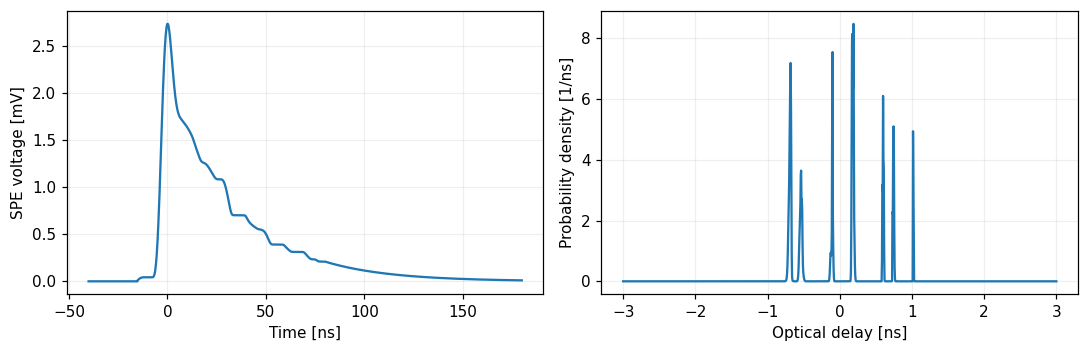

In [3]:
spe_t, spe_v = sii.load_measured_spe_template(instrument.spe_template_path)
charge = sii.load_empirical_charge_factors(instrument.charge_samples_path)
timing = sii.load_optical_timing_mixture(instrument.optical_timing_kernel_path)
star = sii.detected_star_rate_hz(2., instrument)
parameters = pd.DataFrame([
    ['SPE integral',np.trapezoid(spe_v,spe_t),'mV ns','measured'],
    ['charge second moment',np.mean(charge**2),'1','measured samples'],
    ['optical time RMS',timing['rms_spread_ns'],'ns','ray trace'],
    ['sample interval',instrument.sample_width_ns,'ns','main config'],
    ['stellar rate, m_AB=2',star/1e6,'MHz','spectrum + response'],
    ['NSB rate',instrument.detected_nsb_rate_hz/1e6,'MHz','sky model + passband'],
    ['coherence area',instrument.coherence_area_s*1e12,'ps','same passband'],
    ['SII passband width',instrument.optical_width_nm,'nm','scenario'],
], columns=['parameter','value','unit','source'])
parameters.to_csv(OUT/'parameters.csv',index=False)
summary['parameters'] = parameters.to_dict(orient='records')
display(parameters)
time = np.linspace(-3,3,1201)
density = sum(w*np.exp(-.5*((time-m)/s)**2)/(np.sqrt(2*np.pi)*s)
              for w,m,s in zip(timing['weights'],timing['mean_delay_ns'],timing['std_delay_ns']) if s>0)
fig, axes = plt.subplots(1,2,figsize=(10,3.3))
axes[0].plot(spe_t,spe_v); axes[0].set(xlabel='Time [ns]',ylabel='SPE voltage [mV]')
axes[1].plot(time,density); axes[1].set(xlabel='Optical delay [ns]',ylabel='Probability density [1/ns]')
fig.tight_layout(); fig.savefig(FIG/'01_inputs.png'); plt.show()

## 3. 从到达事件到一个镜子的实际波形

以物理HBT倍率1生成24 μs两镜记录。第一幅图是Tel.1前1 μs的探测事件，
第二幅图是一份SPE，第三幅图是这批事件的脉冲叠加并每4 ns采样的电压。
记录计算使用完整时段，图中只放大前1 μs；Tel.2仍保留接收时差。
每个镜子的平均亮度很高，但微弱的跨镜共同涨落尚不可凭肉眼辨认。


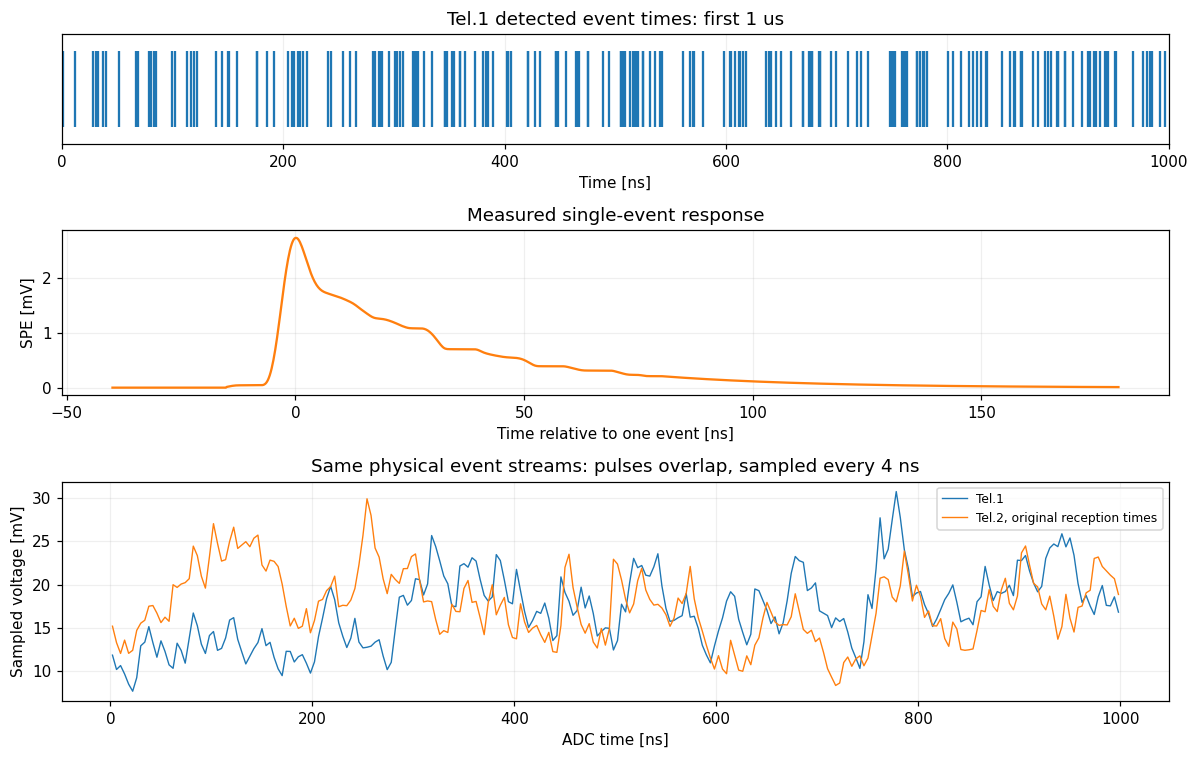

,telescope,events_inside_record,voltage_mean_mv,voltage_rms_mv
0,1,4836,16.785546,4.648827
1,2,4766,16.699444,4.271761


In [4]:
display(walk.single_record(lesson_scene,instrument,FIG,OUT))

## 4. 两镜波形怎样变成相关测量

这里沿用上一节同一条记录。先看原始互相关及预期几何峰位置，再整数移动样本，
把剩余分数时差放入峰模板。C是电压协方差除以两镜电压标准差，**不是理论g²**。
物理峰会淹没在短记录噪声中；额外一图只放大理论峰的纵轴，没有放大注入。
最后的误差棒是固定基线的曝光预测，不是虚构的6小时连续波形。


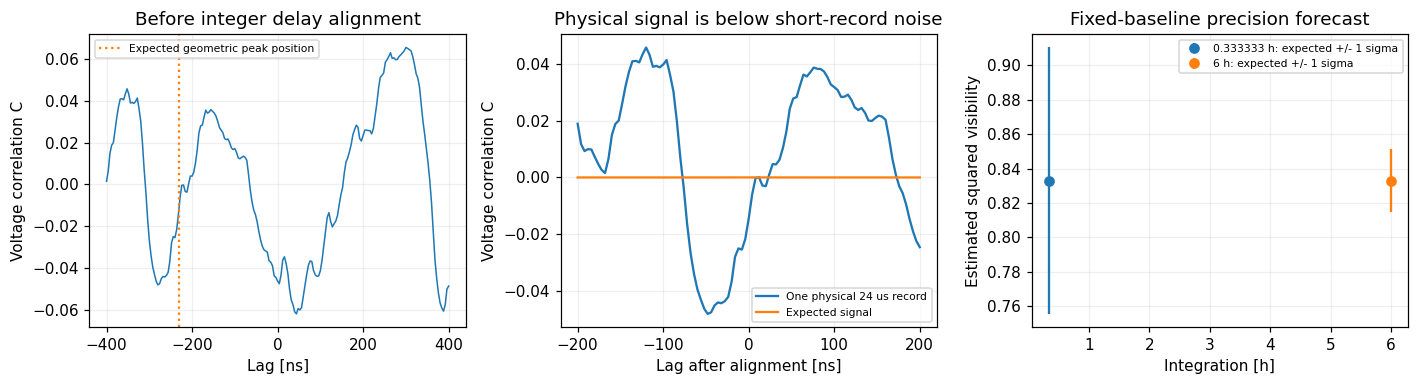

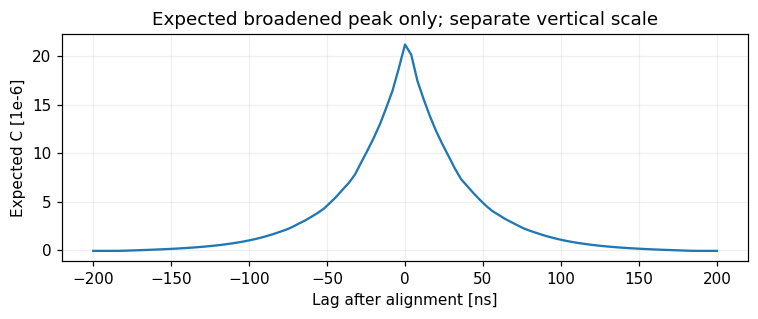

,true_power,estimated_power,sigma_short,effective_record_s,residual_delay_ns,expected_peak,sigma_1200s
0,0.832912,-295.744231,550.860651,0.000024,-0.967249,0.000021,0.077526


In [5]:
lesson_pair=walk.pair_correlation(lesson_scene,instrument,FIG,OUT)
summary['walkthrough_pair']=lesson_pair
display(pd.DataFrame([lesson_pair]))

## 5. 用整个相关峰估计信号及误差

相关函数的相邻滞后点并非独立。下面显示完整峰模板和滞后噪声协方差，
说明GLS为什么不能只取最高点。Monte Carlo与连续响应解析式独立计算。
接下来的探索性UV/图像采用该双镜标定；末尾最终性能另用36镜相位匹配标定。
两条估计器会明确分开，不能将它们的误差数值混用。


,sigma_1200_s,analytic_sigma_1200_s,response_relative_uncertainty,sigma_relative_uncertainty,selected_shrinkage,fine_grid_sigma_ratio,photon_degeneracy
0,0.079267,0.075453,0.006407,0.031281,0.0001,1.0,0.000027


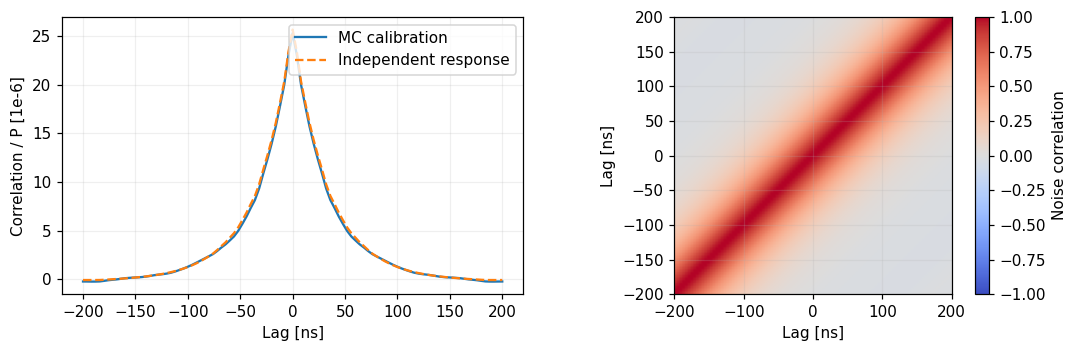

In [6]:
calibration, calibration_diagnostics = sii.simulate_waveform_gls_calibration(
    instrument, null_records=2048, signal_records=512, covariance_shrinkage='auto', seed=SEED)
analytic, analytic_diagnostics = analytic_waveform_calibration(instrument)
analytic_fine, _ = analytic_waveform_calibration(instrument, fine_dt_ns=.025)
sigma_mc = sii.waveform_gls_weights(calibration,1200)[1]
sigma_analytic = sii.waveform_gls_weights(analytic,1200)[1]
summary['calibration'] = {'sigma_1200_s':sigma_mc,'analytic_sigma_1200_s':sigma_analytic,
    'response_relative_uncertainty':calibration.response_relative_uncertainty,
    'sigma_relative_uncertainty':calibration.sigma_relative_uncertainty,
    'selected_shrinkage':calibration.covariance_shrinkage,
    'fine_grid_sigma_ratio':sii.waveform_gls_weights(analytic_fine,1200)[1]/sigma_analytic,
    'photon_degeneracy':analytic_diagnostics['photon_degeneracy']}
np.savez_compressed(OUT/'waveform_calibration.npz',**vars(calibration))
assert abs(summary['calibration']['fine_grid_sigma_ratio']-1)<.01
pd.DataFrame({'lag_ns':calibration.lags_ns,'mc_peak':calibration.peak_per_visibility2,
              'analytic_peak':analytic.peak_per_visibility2}).to_csv(OUT/'response.csv',index=False)
pd.DataFrame(calibration.covariance_per_block).to_csv(OUT/'covariance.csv',index=False)
display(pd.DataFrame([summary['calibration']]))
fig, axes = plt.subplots(1,2,figsize=(10,3.3))
axes[0].plot(calibration.lags_ns,calibration.peak_per_visibility2*1e6,label='MC calibration')
axes[0].plot(analytic.lags_ns,analytic.peak_per_visibility2*1e6,'--',label='Independent response')
axes[0].set(xlabel='Lag [ns]',ylabel='Correlation / P [1e-6]'); axes[0].legend()
corr = calibration.covariance_per_block/np.sqrt(np.outer(np.diag(calibration.covariance_per_block),np.diag(calibration.covariance_per_block)))
im=axes[1].imshow(corr,origin='lower',extent=[-200,200,-200,200],vmin=-1,vmax=1,cmap='coolwarm')
axes[1].set(xlabel='Lag [ns]',ylabel='Lag [ns]'); fig.colorbar(im,ax=axes[1],label='Noise correlation')
fig.tight_layout();fig.savefig(FIG/'02_gls_response.png');plt.show()

## 6. 地球自转把一个镜对扩展成整个UV观测

读取36镜原始位置，按ENU=(-West,North,Up)/100转换，不旋转或平移。
每个20分钟段平均9个时刻、5个波长；6小时共有630条基线、11340条测量。
先看阵列，再比较同一0.16 mas圆盘的连续理论平面、实际采样期望和随机测量。
显示颜色限在0至1，但负测量和大于1的测量均保留在数据及拟合中。
为后面的形态对照同时计算另外三个源，但本节主图仍只展示基准圆盘。


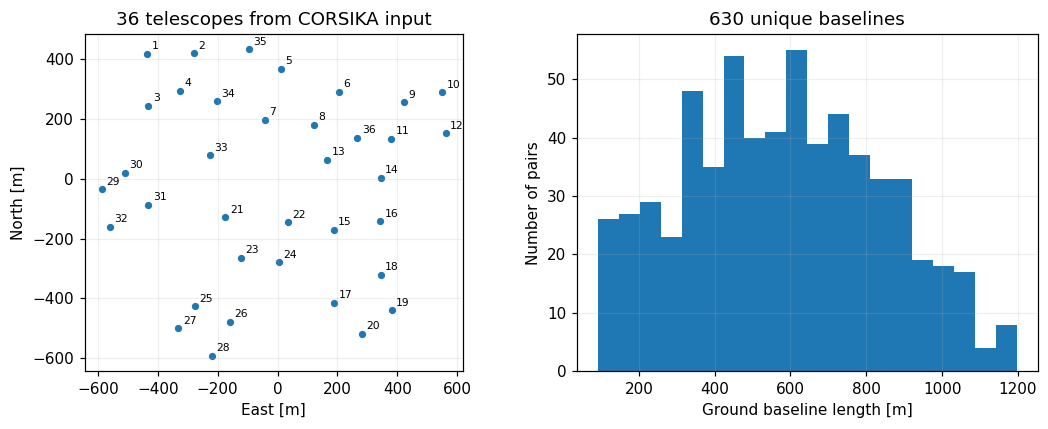

,telescopes,uv_measurements,hours,integration_s_per_measurement,time_subsamples,spectral_nodes,max_baseline_m,expected_hbt_pairs_per_20us
0,36,11340,6,1200,9,5,1197.008534,0.106625


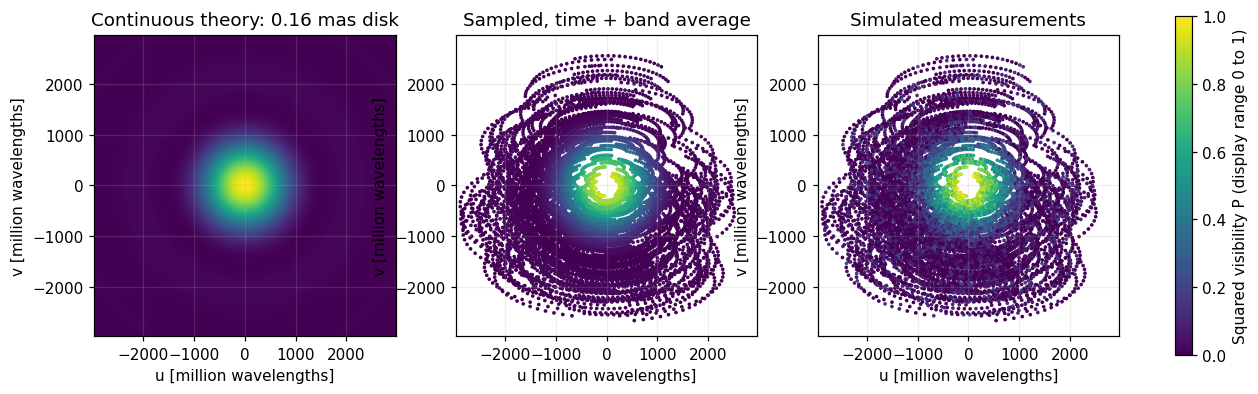

In [7]:
source_cases={'binary':sii.BinarySource(),'single_disk':sii.BinarySource(primary_diameter_mas=.16),
              'ellipse':sii.EllipseSource(),'transit':sii.TransitSource()}
pipelines={}
for index,(case,source) in enumerate(source_cases.items()):
    pipelines[case]=sii.run_sii_pipeline(layout,source,observation,instrument,
        seed=SEED+400+index,source_case=case,estimator='waveform_gls',
        waveform_calibration=calibration,do_reconstruction=False)
frame=pipelines['binary'].measurements
assert len(layout)==36
assert len(frame)==len(layout)*(len(layout)-1)//2*18
baselines=frame.drop_duplicates(['telescope_i_index','telescope_j_index'])[
    ['telescope_i','telescope_j','baseline_east_m','baseline_north_m','baseline_up_m','baseline_m']]
baselines.to_csv(OUT/'array_baselines.csv',index=False)
summary['array_geometry']={'input':'configs/arrays/lact36_20260906.input',
    'coordinate_conversion':'ENU_m = (-west_cm, north_cm, up_cm) / 100',
    'baselines':len(baselines),'min_baseline_m':float(baselines.baseline_m.min()),
    'max_baseline_m':float(baselines.baseline_m.max())}
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].scatter(layout.east_m,layout.north_m,s=14)
for row in layout.itertuples():
    axes[0].annotate(str(row.telescope_id),(row.east_m,row.north_m),xytext=(3,3),
                     textcoords='offset points',fontsize=7)
axes[0].set(xlabel='East [m]',ylabel='North [m]',title='36 telescopes from CORSIKA input')
axes[0].set_aspect('equal')
axes[1].hist(baselines.baseline_m,bins=20)
axes[1].set(xlabel='Ground baseline length [m]',ylabel='Number of pairs',title='630 unique baselines')
fig.tight_layout();fig.savefig(FIG/'08_array_layout.png');plt.show()
fig,axes=plt.subplots(1,2,figsize=(10,4))
for ax,column,title in zip(axes,['visibility2_true','visibility2_measured'],['Time + band averaged truth','Simulated measurement']):
    im=ax.scatter(frame.u_lambda/1e6,frame.v_lambda/1e6,c=frame[column],s=3,cmap='viridis',vmin=-.2,vmax=1.2)
    ax.set(xlabel='u [Mlambda]',ylabel='v [Mlambda]',title=title);ax.set_aspect('equal')
fig.colorbar(im,ax=axes,label='Squared visibility',fraction=.025)
fig.savefig(FIG/'04_uv_measurements.png',bbox_inches='tight');plt.close(fig)
frame.drop(columns=['uv_samples_u','uv_samples_v','uv_samples_weight']).to_csv(OUT/'binary_measurements.csv',index=False)
summary['observation']={'telescopes':len(layout),'uv_measurements':len(frame),'hours':6,
    'integration_s_per_measurement':1200,'time_subsamples':9,'spectral_nodes':5,
    'max_baseline_m':float(frame.baseline_m.max()),
    'expected_hbt_pairs_per_20us':star**2*instrument.coherence_area_s*20e-6}
display(pd.DataFrame([summary['observation']]))
walk.array_and_model_views(pipelines,instrument,observation,FIG,OUT)

## 7. 改变形态、角直径，观测会怎样变

仪器、总AB星等2、阵列、赤纬和曝光保持不变。现在明确改变天空形态，参数列在下表；
`single_disk`只使用对象中的主星直径，双星字段不参与圆盘计算。
随后只改变均匀圆盘直径0.08/0.16/0.32 mas，看零点移动和实际基线测到的功率分布。
这些是理论期望的变化；星等和曝光对噪声的影响在第9节单独看。


,source_case,ab_magnitude,separation_mas,position_angle_deg,flux_ratio_secondary_to_primary,primary_diameter_mas,secondary_diameter_mas,major_diameter_mas,minor_diameter_mas,stellar_diameter_mas,planet_diameter_mas,planet_east_offset_mas,planet_north_offset_mas
0,binary,2.0,0.2,35.0,0.55,0.06,0.04,—,—,—,—,—,—
1,single_disk,2.0,0.2,35.0,0.55,0.16,0.04,—,—,—,—,—,—
2,ellipse,2.0,—,35.0,—,—,—,0.24,0.12,—,—,—,—
3,transit,2.0,—,—,—,—,—,—,—,0.3,0.08,0.06,0.03


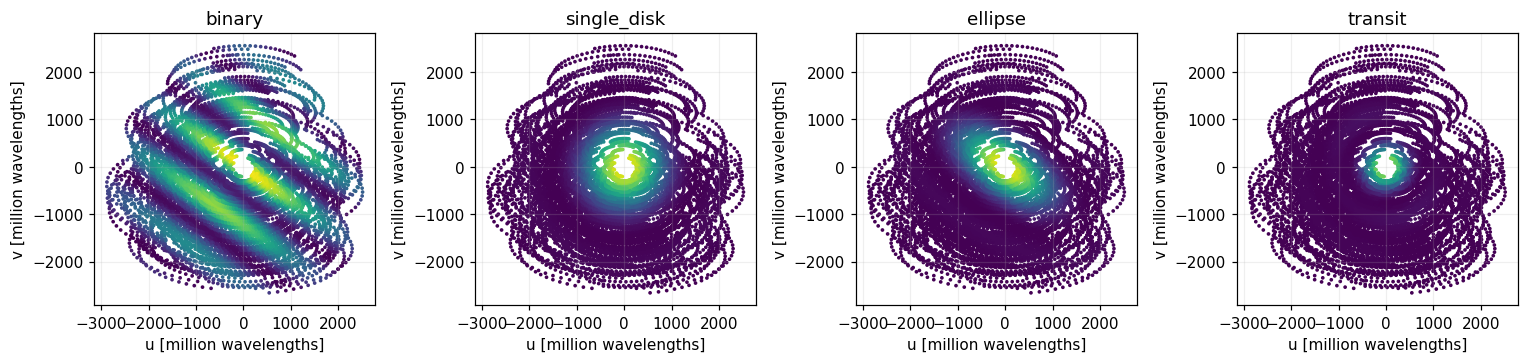

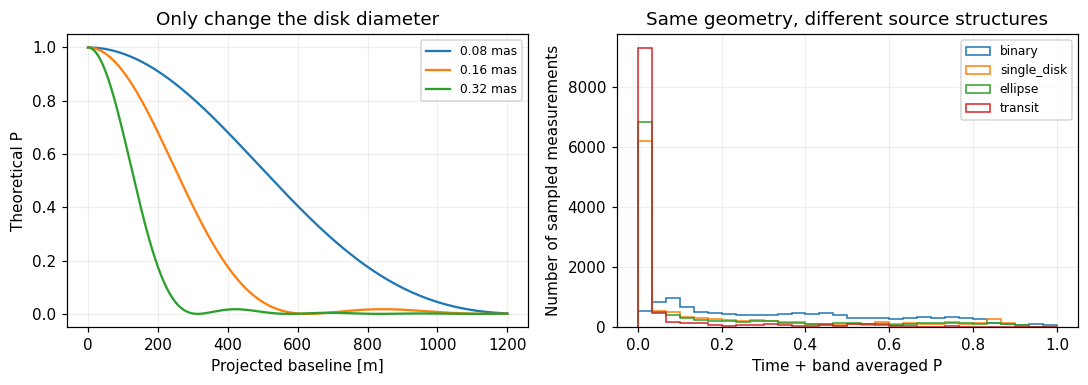

In [8]:
display(pd.DataFrame([{'source_case':case,**asdict(source)} for case,source in source_cases.items()]).fillna('—'))
walk.model_views(pipelines,instrument,FIG)

## 8. 用观测反推角直径，或者尝试恢复图像

先在已知圆盘模型族中拟合角直径及共同标定增益，看剖面曲线和重复覆盖率。
再放宽为非负像素图像重建。图像的问题更不适定；真图只用于事后评价，
不能据看起来像遮挡的暗区宣布发现行星。这里使用第5节双镜标定的探索性分支。


,estimate,low,high,touches_boundary,disconnected
0,0.1601,0.15944,0.160849,False,False


,assumed_sigma_scale,covered,trials,coverage,binomial_ci_low,binomial_ci_high,boundary_intervals,disconnected_intervals
0,1.00000,959,1000,0.959,0.944788,0.970420,0,0
1,0.93869,942,1000,0.942,0.925664,0.955667,0,0
2,1.06131,971,1000,0.971,0.958615,0.980494,0,0


,source,time_nodes,reference_time_nodes,max_abs_P_difference,rms_difference_over_row_sigma
0,binary,9,27,0.000068,0.000135
1,single_disk,9,27,0.000006,0.000014
2,ellipse,9,27,0.000011,0.000017
3,transit,9,27,0.000006,0.000009


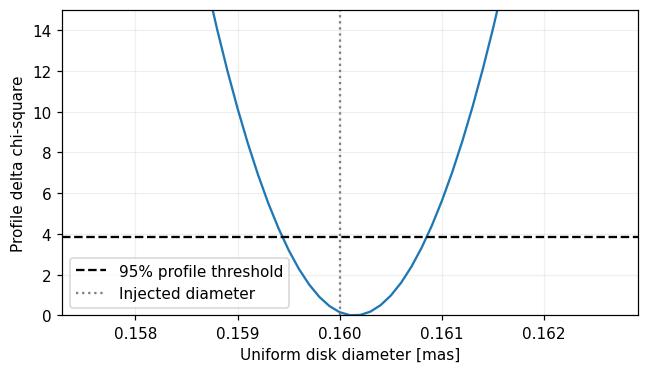

In [9]:
parameter_uv=sii.prepare_reconstruction_uv(pipelines['single_disk'].measurements,cell_mlambda=120.)
sample_u,sample_v,group,fraction=parameter_uv.sampling
radius=np.hypot(sample_u,sample_v)
diameter_grid=np.linspace(.12,.20,801)
models=np.array([np.bincount(group,weights=fraction*sii.uniform_disk_visibility(radius,diameter)**2,
                            minlength=len(parameter_uv.u_lambda)) for diameter in diameter_grid])
statistic,_=profile_model_grid(parameter_uv,models)
interval=profile_grid_interval(diameter_grid,statistic[0])
summary['diameter_interval']=interval
pd.DataFrame({'diameter_mas':diameter_grid,'delta_chi2':statistic[0]-statistic[0].min()}).to_csv(OUT/'diameter_profile.csv',index=False)
rng=np.random.default_rng(SEED+900)
model_true=models[400]
realizations=(1+rng.normal(0,parameter_uv.calibration_relative_sigma,(1000,1)))*model_true
realizations+=rng.normal(0,parameter_uv.sigma,(1000,len(model_true)))
coverage_rows=[]
for scale in [1.,1-1.96*calibration.sigma_relative_uncertainty,1+1.96*calibration.sigma_relative_uncertainty]:
    scaled=replace(parameter_uv,sigma=parameter_uv.sigma*scale)
    statistics,_=profile_model_grid(scaled,models,realizations)
    intervals=[profile_grid_interval(diameter_grid,row) for row in statistics]
    covered=sum(row['low']<=.16<=row['high'] for row in intervals)
    lower,upper=proportion_interval(covered,len(intervals))
    coverage_rows.append({'assumed_sigma_scale':scale,'covered':covered,'trials':len(intervals),
        'coverage':covered/len(intervals),'binomial_ci_low':lower,'binomial_ci_high':upper,
        'boundary_intervals':sum(row['touches_boundary'] for row in intervals),
        'disconnected_intervals':sum(row['disconnected'] for row in intervals)})
coverage_table=pd.DataFrame(coverage_rows)
coverage_table.to_csv(OUT/'diameter_coverage.csv',index=False)
summary['diameter_coverage']=coverage_rows
fine_observation=replace(observation,visibility_subsamples_per_segment=27)
quadrature_rows=[]
for case,source in source_cases.items():
    coarse=pipelines[case].measurements.visibility2_true.to_numpy()
    fine=sii.segment_averaged_visibility2(pipelines[case].uvw,source,fine_observation,instrument,case)
    quadrature_rows.append({'source':case,'time_nodes':9,'reference_time_nodes':27,
        'max_abs_P_difference':float(np.max(abs(coarse-fine))),
        'rms_difference_over_row_sigma':float(np.sqrt(np.mean((coarse-fine)**2))/sigma_mc)})
summary['time_quadrature']=quadrature_rows
pd.DataFrame(quadrature_rows).to_csv(OUT/'time_quadrature.csv',index=False)
display(pd.DataFrame([interval]));display(coverage_table);display(pd.DataFrame(quadrature_rows))
fig,ax=plt.subplots(figsize=(6,3.5))
ax.plot(diameter_grid,statistic[0]-statistic[0].min())
ax.axhline(3.84145882,color='k',ls='--',label='95% profile threshold')
ax.axvline(.16,color='gray',ls=':',label='Injected diameter')
width=interval['high']-interval['low']
ax.set(xlabel='Uniform disk diameter [mas]',ylabel='Profile delta chi-square',
       xlim=(interval['estimate']-2*width,interval['estimate']+2*width),ylim=(0,15))
ax.legend();fig.tight_layout();fig.savefig(FIG/'07_diameter_profile.png');plt.show()

In [10]:
GRID=32
FOV=.70
fits={}; kernels={}; uv_data={}
reconstruction_rows=[]
for index,(case,pipeline) in enumerate(pipelines.items()):
    uv=sii.prepare_reconstruction_uv(pipeline.measurements,cell_mlambda=120.)
    kernel=reco.power_sampling_kernel(uv,GRID,FOV)
    fit=reco.reconstruct_uv_data(uv,grid_size=GRID,fov_mas=FOV,support_radius_mas=.32,
        starts=3,max_iter=8000,smoothness='cv',smoothness_candidates=(0.,1e-4,.01),
        seed=SEED+500+index,_power_kernel=kernel)
    fits[case]=fit;kernels[case]=kernel;uv_data[case]=uv
    reconstruction_rows.append({'source':case,'constraints':len(uv.u_lambda),
        'converged':fit.metrics['optimizer_success'],'chi2_per_point':fit.metrics['chi2']/len(uv.u_lambda),
        'gain':fit.metrics['calibration_gain'],'gain_sigma':fit.metrics['calibration_gain_posterior_sigma'],
        'smoothness':fit.metrics['smoothness'],'stationarity_gap':fit.metrics['simplex_stationarity_gap'],
        'stationarity_passed':fit.metrics['stationarity_passed'],
        'iterations':fit.metrics['optimizer_iterations'],
        'training_all_converged':all(row['training_converged'] for row in fit.metrics['smoothness_selection'])})
    np.save(OUT/(case+'_image.npy'),fit.image)
reconstruction_table=pd.DataFrame(reconstruction_rows)
reconstruction_table.to_csv(OUT/'reconstruction.csv',index=False)
summary['reconstruction']=reconstruction_table.to_dict(orient='records')
display(reconstruction_table)

,source,constraints,converged,chi2_per_point,gain,gain_sigma,smoothness,stationarity_gap,stationarity_passed,iterations,training_all_converged
0,binary,1448,True,0.918088,1.015132,0.001642,0.0001,0.025374,True,1725,True
1,single_disk,1448,True,1.071930,1.016379,0.002267,0.0100,0.014688,True,472,True
2,ellipse,1448,True,0.977754,1.018196,0.002409,0.0100,0.027592,True,669,True
3,transit,1448,True,0.943680,1.004056,0.004012,0.0100,0.016613,True,779,True


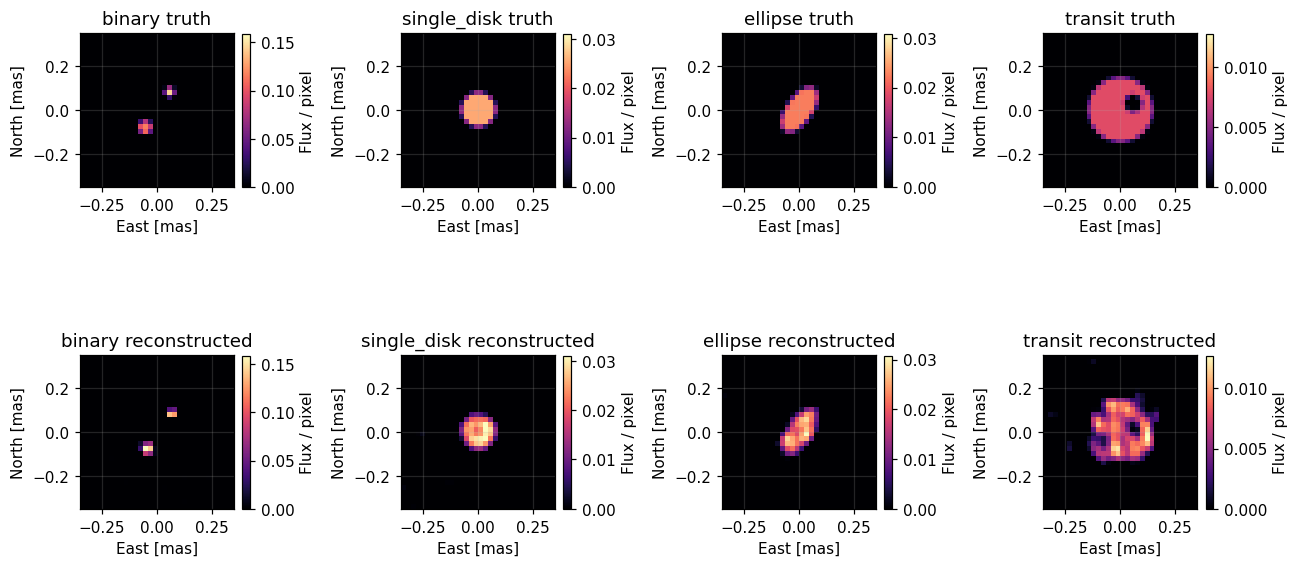

In [11]:
def truth_image(case,source,theta):
    # 子像素面积平均仅用于拟合后的真图评价；不作为重建器输入。
    step=theta[1]-theta[0]
    offsets=(np.arange(8)+.5)/8-.5
    high=(theta[:,None]+offsets*step).ravel()
    y,x=np.meshgrid(high,high,indexing='ij')
    if case in ('binary','single_disk'):
        pa=np.deg2rad(source.position_angle_deg)
        dx=.5*source.separation_mas*np.sin(pa) if case=='binary' else 0.
        dy=.5*source.separation_mas*np.cos(pa) if case=='binary' else 0.
        image=(((x+dx)**2+(y+dy)**2)<=(source.primary_diameter_mas/2)**2).astype(float)
        image/=image.sum()
        if case=='binary':
            secondary=(((x-dx)**2+(y-dy)**2)<=(source.secondary_diameter_mas/2)**2).astype(float)
            image+=source.flux_ratio_secondary_to_primary*secondary/secondary.sum()
    elif case=='ellipse':
        pa=np.deg2rad(source.position_angle_deg)
        major=x*np.sin(pa)+y*np.cos(pa);minor=x*np.cos(pa)-y*np.sin(pa)
        image=((major/(source.major_diameter_mas/2))**2+(minor/(source.minor_diameter_mas/2))**2<=1).astype(float)
    else:
        image=(x*x+y*y<=(source.stellar_diameter_mas/2)**2).astype(float)
        image[((x-source.planet_east_offset_mas)**2+(y-source.planet_north_offset_mas)**2)<=(source.planet_diameter_mas/2)**2]=0
    image=image.reshape(len(theta),8,len(theta),8).mean(axis=(1,3))
    return image/image.sum()

truths={}; alignment_rows=[]
fig,axes=plt.subplots(2,4,figsize=(12,6))
for column,(case,source) in enumerate(source_cases.items()):
    fit=fits[case];truth=truth_image(case,source,fit.theta_mas);truths[case]=truth
    aligned,metrics=reco._best_truth_alignment(fit.image,truth)
    alignment_rows.append({'source':case,**{k:v for k,v in metrics.items() if np.isscalar(v)}})
    for row,image in enumerate([truth,aligned]):
        im=axes[row,column].imshow(image,origin='lower',extent=[-.35,.35,-.35,.35],cmap='magma',
                                  vmin=0,vmax=max(truth.max(),aligned.max()))
        axes[row,column].set(xlabel='East [mas]',ylabel='North [mas]',title=case+(' truth' if row==0 else ' reconstructed'))
        fig.colorbar(im,ax=axes[row,column],fraction=.045,label='Flux / pixel')
fig.tight_layout();fig.savefig(FIG/'05_reconstruction.png');plt.show()
pd.DataFrame(alignment_rows).to_csv(OUT/'image_alignment.csv',index=False)
summary['image_alignment']=alignment_rows

## 9. 最后看性能：哪些条件下能测得准

这里切换到最终36镜相位匹配估计器：实际生成共享ADC，独立训练响应和零信号噪声，
把标定误差、段内相位和弱光共镜误差修正传入角直径推断。
固定星等2/4/6、直径0.08/0.16/0.32 mas、曝光1/3/6小时，逐项与基准比较。
三幅主图依次展示精度、区间覆盖率及规格书暗计数影响。低信噪比触边结果照常保留。


,hours,magnitude,diameter_mas,method,trials,bias_mas,rmse_mas,std_mas,median_width_mas,coverage,covered,coverage_ci_low,coverage_ci_high,boundary_intervals,disconnected_intervals,compression_error_sigma,sigma_visibility2_median,assumed_noise_inflation
36,6.0,2.0,0.08,profile_gain,500,0.000001,0.000131,0.000131,0.000509,0.950,475,0.927072,0.967385,0,0,1.057917e-12,0.078296,1.006070
38,6.0,2.0,0.16,profile_gain,500,-0.000021,0.000361,0.000361,0.001429,0.960,480,0.938897,0.975399,0,0,1.057917e-12,0.078296,1.006070
40,6.0,2.0,0.32,profile_gain,500,-0.000100,0.001334,0.001332,0.005286,0.940,470,0.915451,0.959156,0,0,1.057917e-12,0.078296,1.006070
42,6.0,4.0,0.08,profile_gain,500,-0.000061,0.000712,0.000710,0.002851,0.964,482,0.943700,0.978527,0,0,4.664611e-13,0.501120,1.005283
44,6.0,4.0,0.16,profile_gain,500,-0.000039,0.001820,0.001821,0.007425,0.966,483,0.946120,0.980071,0,0,4.664611e-13,0.501120,1.005283
46,6.0,4.0,0.32,profile_gain,500,-0.000115,0.006091,0.006096,0.022855,0.934,467,0.908557,0.954137,0,0,4.664611e-13,0.501120,1.005283
48,6.0,6.0,0.08,profile_gain,500,0.000213,0.004063,0.004061,0.016765,0.956,478,0.934139,0.972223,0,0,7.190546e-14,3.459786,1.005159
50,6.0,6.0,0.16,profile_gain,500,0.001491,0.013039,0.012966,0.048336,0.946,473,0.922403,0.964116,0,0,7.190546e-14,3.459786,1.005159
52,6.0,6.0,0.32,profile_gain,500,0.005752,0.042320,0.041969,0.162720,0.952,476,0.929419,0.969007,22,0,7.190546e-14,3.459786,1.005159


,magnitude,photon_degeneracy,normalized_cross_spectrum_bound,bartlett_covariance_operator_bound,bartlett_sigma_inflation_bound,thermal_count_covariance_operator_bound,count_bin_ns,thermal_count_connected_diagonal_fraction
0,2.0,2.667107e-05,2.575655e-05,0.001855,0.000927,0.001896,4.0,0.000033
1,4.0,4.227079e-06,4.021088e-06,0.000290,0.000145,0.000323,4.0,0.000032
2,6.0,6.699469e-07,5.823477e-07,0.000042,0.000021,0.000069,4.0,0.000027


,hours,effect,max_abs_power_delta,max_relative_sigma_delta,diameter_mas,fitted_bias_mas
0,1.0,phase_time_1200_to_2400,0.000000e+00,1.861881e-05,0.00,0.000000
1,1.0,diameter_model_interpolation_sigma,4.345538e-09,5.265394e-07,0.00,0.000000
2,3.0,phase_time_1200_to_2400,0.000000e+00,1.861881e-05,0.00,0.000000
3,3.0,diameter_model_interpolation_sigma,4.345538e-09,8.752787e-07,0.00,0.000000
4,6.0,phase_time_1200_to_2400,0.000000e+00,1.780358e-05,0.00,0.000000
5,6.0,diameter_model_interpolation_sigma,4.351346e-09,1.109980e-06,0.00,0.000000
6,6.0,uniform_pupil_radius_4m,3.616040e-05,0.000000e+00,0.08,-0.000001
7,6.0,pupil_quadrature_12x24_to_18x36,2.584348e-10,0.000000e+00,0.08,0.000000
8,6.0,uniform_pupil_radius_4m,1.335425e-04,0.000000e+00,0.16,-0.000010
9,6.0,pupil_quadrature_12x24_to_18x36,9.542743e-10,0.000000e+00,0.16,0.000000


,magnitude,summed_channels,rating,dark_rate_mhz,sigma_ratio,temperature_c,overvoltage_v
0,2.0,1,typical,1.2,1.005986,25,8.5
1,2.0,1,max,3.0,1.014965,25,8.5
2,2.0,8,typical,9.6,1.047889,25,8.5
3,2.0,8,max,24.0,1.119723,25,8.5
4,4.0,1,typical,1.2,1.037205,25,8.5
5,4.0,1,max,3.0,1.093013,25,8.5
6,4.0,8,typical,9.6,1.297642,25,8.5
7,4.0,8,max,24.0,1.744105,25,8.5
8,6.0,1,typical,1.2,1.214508,25,8.5
9,6.0,1,max,3.0,1.536269,25,8.5


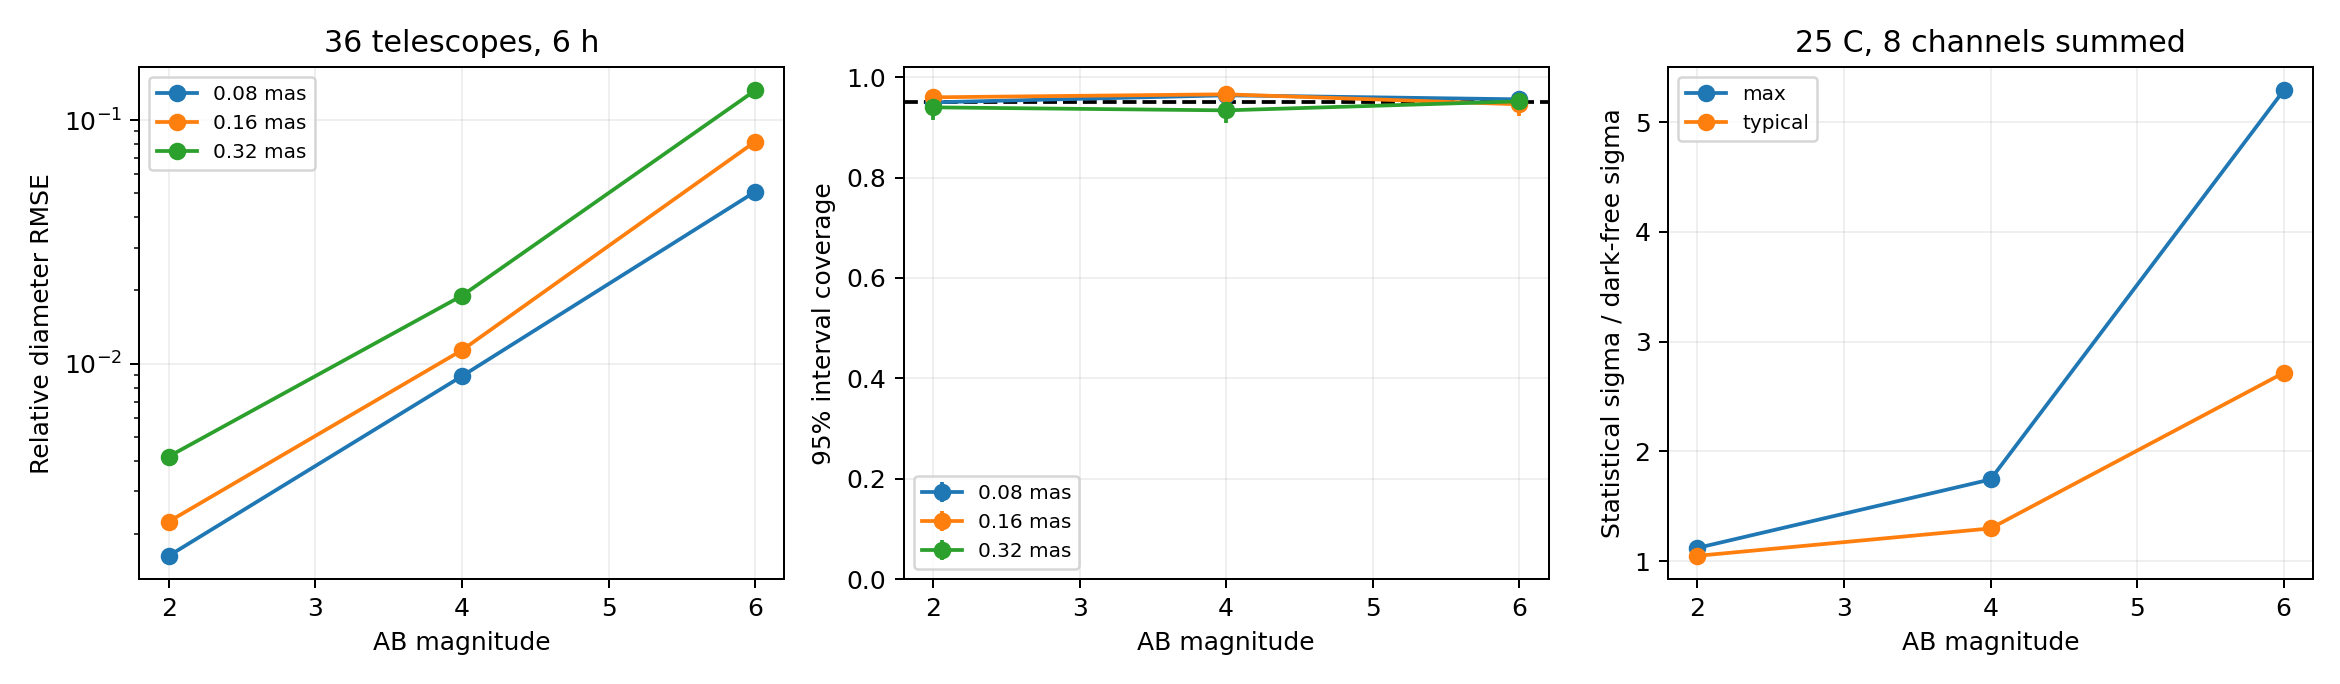

In [12]:
import subprocess
subprocess.run([sys.executable,'-X','utf8',str(ROOT/'tools/validate_sii_performance.py')],cwd=ROOT,check=True)
performance_dir=ROOT/'validation/sii_performance'
performance_summary=json.loads((performance_dir/'summary.json').read_text(encoding='utf-8'))
assert all(performance_summary['checks'].values())
summary['performance']={
    'execution':'fresh full-array short records and fixed performance suite executed by this notebook',
    'summary_sha256_lf':hashlib.sha256((performance_dir/'summary.json').read_bytes().replace(b'\r\n',b'\n')).hexdigest(),
    'raw':performance_summary['raw'],'scenarios':performance_summary['scenarios']}
display(pd.read_csv(performance_dir/'performance.csv').query("method == 'profile_gain' and hours == 6"))
display(pd.read_csv(performance_dir/'covariance_budget.csv'))
display(pd.read_csv(performance_dir/'approximation_budget.csv'))
display(pd.read_csv(performance_dir/'datasheet_scenarios.csv'))
display(__import__('IPython.display',fromlist=['Image']).Image(filename=str(performance_dir/'performance.png')))

## 附加验证：需要核查细节时再读

以下单元仍完整执行并保留原始结果。它们检查理论生成、独立样本、插值、追踪及图像稳定性，
不是主线中的另一颗基准恒星。每项验证的特殊参数和注入倍率在本节说明。


### A. 等权热光模的独立物理对照

以下计算从相关复高斯热光模开始，再做条件泊松探测。它不调用共享光电子对生成器。
这里每条记录包含16个独立模，用于检验Siegert关系和热光超泊松方差；不是LACT的实际相干模数。


In [13]:
counts, intensity = thermal_mode_counts(np.random.default_rng(SEED), 300000, 6., 2., .6)
thermal = pd.DataFrame([
    ['mean intensity',1.,intensity[:,0].mean()],
    ['intensity covariance',.6/16,np.cov(intensity.T)[0,1]],
    ['mean detected count',8.,counts[:,0].mean()],
    ['count variance',8.+36/16,counts[:,0].var(ddof=1)],
    ['count covariance',36*.6/16,np.cov(counts.T)[0,1]],
],columns=['quantity','theory','simulation'])
thermal['relative_difference'] = thermal.simulation/thermal.theory-1
assert np.max(abs(thermal.relative_difference)) < .04
thermal.to_csv(OUT/'thermal_modes.csv',index=False)
summary['thermal_modes'] = thermal.to_dict(orient='records')
display(thermal)

,quantity,theory,simulation,relative_difference
0,mean intensity,1.0000,1.000313,0.000313
1,intensity covariance,0.0375,0.037525,0.000655
2,mean detected count,8.0000,7.997673,-0.000291
3,count variance,10.2500,10.268915,0.001845
4,count covariance,1.3500,1.329592,-0.015117


### B. 独立留出与实际记录长度

这些样本不参与标定，也不重新调节权重。标准差区间来自有限样本的卡方区间。
放大注入只用于验证响应斜率；实际场景的HBT对率仍按物理值计算。
不同块长检验的是实际短波形统计，不是直接画预设的T的负二分之一次方曲线。


,kind,batch,estimator,mean_over_sigma,std_over_sigma,std_ci_low,std_ci_high
0,null,0,MC,0.0584,1.0234,0.9643,1.0902
1,null,0,analytic,0.0403,1.0184,0.9596,1.0849
2,null,1,MC,-0.0080,1.0589,0.9978,1.1281
3,null,1,analytic,0.0198,1.0574,0.9963,1.1264
4,null,2,MC,0.0687,0.9845,0.9277,1.0489
5,null,2,analytic,0.0489,0.9625,0.9070,1.0254


,scale,estimator,response,sem
0,1000.0,MC,1.01305,0.04481
1,1000.0,analytic,0.97831,0.04190
2,3000.0,MC,0.99519,0.01670
3,3000.0,analytic,0.99574,0.01495
4,10000.0,MC,1.00634,0.00510
5,10000.0,analytic,1.00163,0.00493


,duration_us,std_over_sigma,ci_low,ci_high
0,10.0,1.082296,0.995962,1.185146
1,40.0,0.993427,0.914182,1.087832


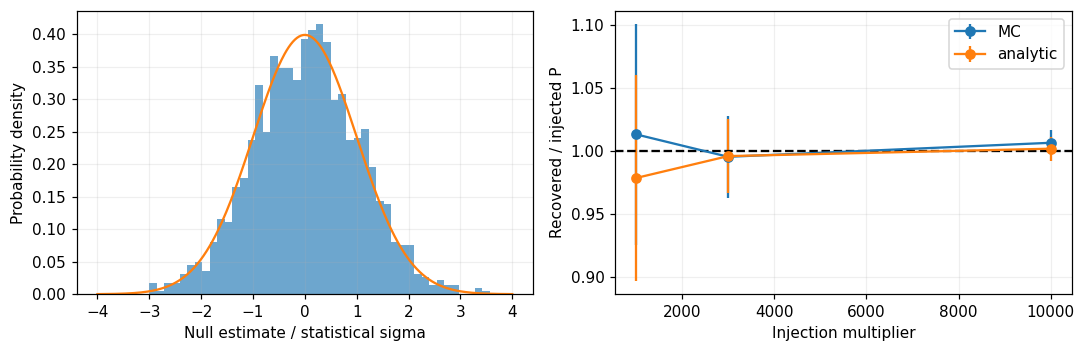

In [14]:
validation_rows=[]
independent_null=[]
for batch in range(3):
    _, records=waveform_records(instrument,512,SEED+100+batch)
    independent_null.append(records)
    for name,cal in [('MC',calibration),('analytic',analytic)]:
        values,sigma=sii.estimate_visibility2_gls(records,cal)
        ci=standard_deviation_interval(values)/sigma
        validation_rows.append({'kind':'null','batch':batch,'estimator':name,
            'mean_over_sigma':float(values.mean()/sigma),'std_over_sigma':float(values.std(ddof=1)/sigma),
            'std_ci_low':ci[0],'std_ci_high':ci[1]})
validation_table=pd.DataFrame(validation_rows)
validation_table.to_csv(OUT/'independent_null.csv',index=False)
display(validation_table.round(4))
scale_rows=[]
for index,scale in enumerate([1000.,3000.,10000.]):
    _,records=waveform_records(instrument,192,SEED+200+index,visibility2=1.,pair_scale=scale)
    for name,cal in [('MC',calibration),('analytic',analytic)]:
        values,_=sii.estimate_visibility2_gls(records,cal)
        scale_rows.append({'scale':scale,'estimator':name,'response':float(values.mean()/scale),
                           'sem':float(values.std(ddof=1)/np.sqrt(len(values))/scale)})
scale_table=pd.DataFrame(scale_rows)
scale_table.to_csv(OUT/'injection_scale.csv',index=False)
display(scale_table.round(5))
duration_rows=[]
for index,duration in enumerate([10000.,40000.]):
    _,records=waveform_records(instrument,256,SEED+300+index,duration_ns=duration)
    values,sigma=sii.estimate_visibility2_gls(records,calibration,exposure_s=duration*1e-9)
    ci=standard_deviation_interval(values)/sigma
    duration_rows.append({'duration_us':duration/1000,'std_over_sigma':values.std(ddof=1)/sigma,
                          'ci_low':ci[0],'ci_high':ci[1]})
duration_table=pd.DataFrame(duration_rows)
duration_table.to_csv(OUT/'block_duration.csv',index=False)
summary['independent_null']=validation_table.to_dict(orient='records')
summary['injection_scales']=scale_table.to_dict(orient='records')
summary['block_durations']=duration_table.to_dict(orient='records')
display(duration_table)
fig,axes=plt.subplots(1,2,figsize=(10,3.3))
values,sigma=sii.estimate_visibility2_gls(np.concatenate(independent_null),calibration)
axes[0].hist(values/sigma,bins=45,density=True,alpha=.65)
x=np.linspace(-4,4,400);axes[0].plot(x,np.exp(-x*x/2)/np.sqrt(2*np.pi))
axes[0].set(xlabel='Null estimate / statistical sigma',ylabel='Probability density')
for label,g in scale_table.groupby('estimator'):
    axes[1].errorbar(g.scale,g.response,yerr=1.96*g['sem'],fmt='o-',label=label)
axes[1].axhline(1.,color='k',ls='--');axes[1].set(xlabel='Injection multiplier',ylabel='Recovered / injected P')
axes[1].legend();fig.tight_layout();fig.savefig(FIG/'03_independent_checks.png');plt.show()

### C. 三镜插值核与较长记录对照

本节实际重新运行联合观测入口，不读取上次保存的结果来代替计算。
同一台望远镜的ADC由所有相关基线共享。先检验注入后的时延补偿、独立留出和零信号，
再让16至512点半宽使用同一批光子和相同时间区间，检查响应与噪声变化。
512点是数值参考，不代表连续模拟真值；误差棒利用同记录的配对差，保留方法间相关性。
另用独立生成的96 μs物理倍率记录对照24 μs记录的曝光缩放。

下方图表由本节执行生成。三镜弱对过程与独立热光模基准各有适用范围，
较长记录检验仍局限于微秒级，不足以证明整夜状态平稳。


calibration: 128/256
calibration: 256/256
injection_holdout: 128/384
injection_holdout: 256/384
injection_holdout: 384/384
physical_scale: 128/384
physical_scale: 256/384
physical_scale: 384/384
null: 128/384
null: 256/384
null: 384/384
long_physical_scale: 128/384
long_physical_scale: 256/384
long_physical_scale: 384/384
{
  "checks": [
    {
      "name": "independent_injection_response",
      "max_abs_z": 3.110526856847091,
      "passed": true
    },
    {
      "name": "independent_null_mean",
      "max_abs_z": 1.1742568341182857,
      "passed": true
    },
    {
      "name": "whole_record_vs_four_blocks",
      "max_abs_z": 0.6255215278190601,
      "passed": true
    },
    {
      "name": "independent_thermal_moments",
      "max_abs_z": 1.441621425541838,
      "passed": true
    },
    {
      "name": "independent_long_record_noise_scaling",
      "min_scaled_sigma_ratio": 0.9266612171631248,
      "max_scaled_sigma_ratio": 0.9773990431316947,
      "passed": true
    }
 

,name,max_abs_z,passed,min_scaled_sigma_ratio,max_scaled_sigma_ratio
0,independent_injection_response,3.110527,True,NaN,NaN
1,independent_null_mean,1.174257,True,NaN,NaN
2,whole_record_vs_four_blocks,0.625522,True,NaN,NaN
3,independent_thermal_moments,1.441621,True,NaN,NaN
4,independent_long_record_noise_scaling,NaN,True,0.926661,0.977399


,half_width,baseline,common_duration_s,reference_half_width,response,response_sem,response_minus_reference,paired_sem,noise_std_ratio_to_reference
0,16,0-1,0.000019,512,0.943187,0.006593,-0.000367,0.000724,0.984313
1,16,0-2,0.000019,512,1.003431,0.013206,-0.000145,0.000314,0.998962
2,16,1-2,0.000019,512,0.910565,0.009391,0.000924,0.001089,0.979182
3,32,0-1,0.000019,512,0.943769,0.006666,0.000216,0.000492,0.992053
4,32,0-2,0.000019,512,1.003472,0.013208,-0.000104,0.000218,0.999089
5,32,1-2,0.000019,512,0.910465,0.009458,0.000824,0.000748,0.991822
6,64,0-1,0.000019,512,0.943667,0.006698,0.000113,0.000326,0.995658
7,64,0-2,0.000019,512,1.003537,0.013219,-0.000039,0.000147,0.999506
8,64,1-2,0.000019,512,0.910115,0.009512,0.000474,0.000478,0.997299
9,128,0-1,0.000019,512,0.943532,0.006706,-0.000022,0.000190,0.997384


,baseline,short_exposure_s,long_exposure_s,scaled_sigma_ratio,low_95,high_95
0,0-1,0.000023,0.000095,0.977399,0.884123,1.080516
1,0-2,0.000023,0.000095,0.926661,0.838227,1.024425
2,1-2,0.000023,0.000095,0.966866,0.874595,1.068871


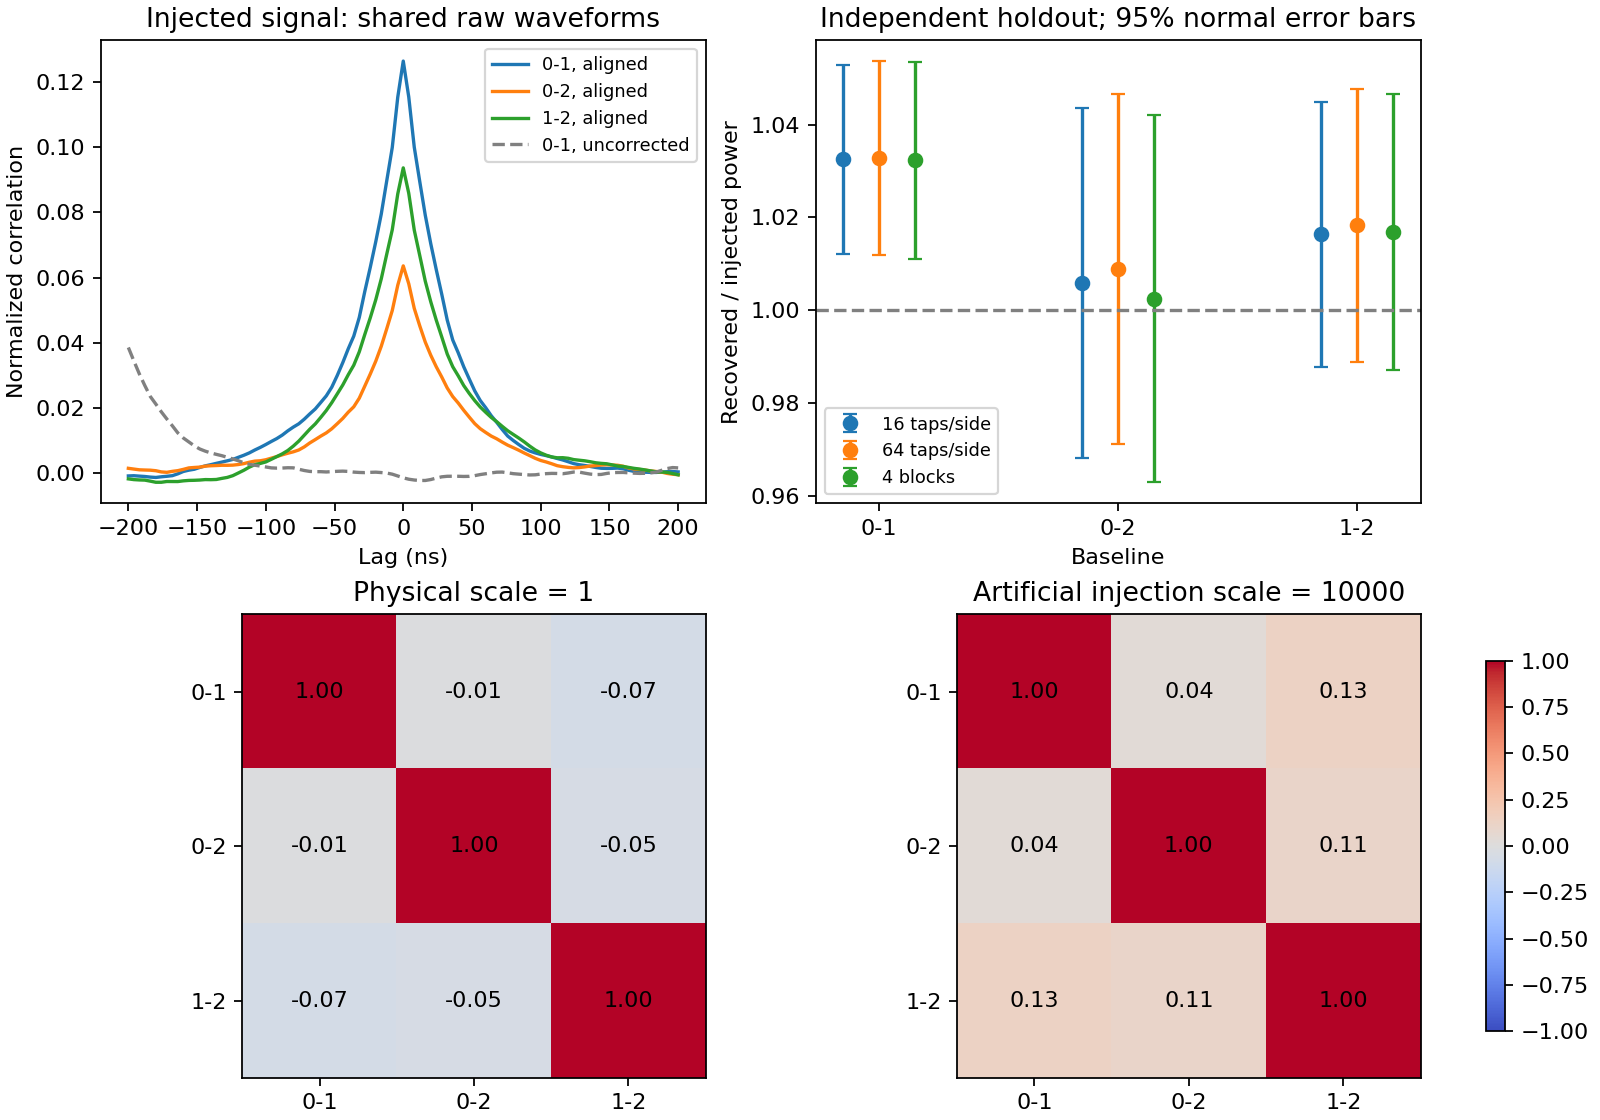

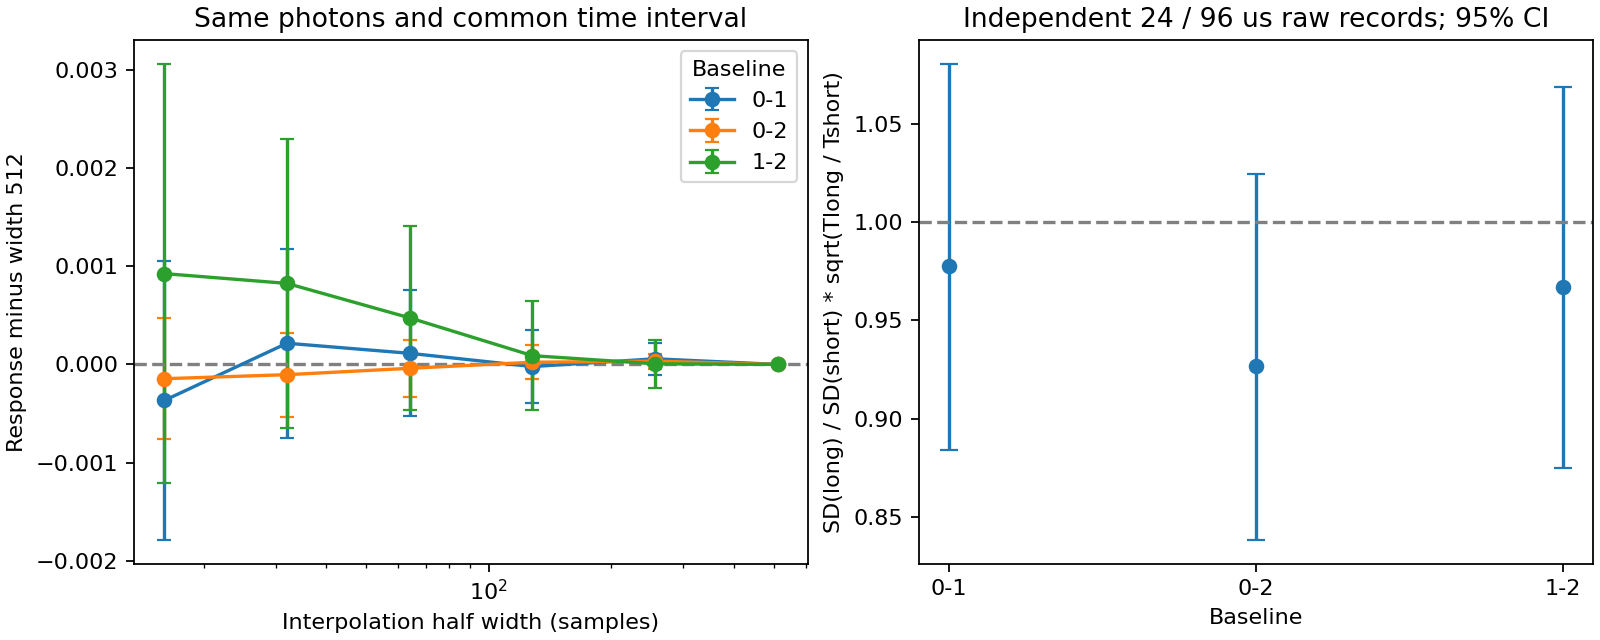

In [15]:
import subprocess
from IPython.display import Image
completed = subprocess.run([sys.executable, '-X', 'utf8', str(ROOT/'tools/validate_sii_observation.py')],
                           cwd=ROOT, capture_output=True, text=True, encoding='utf-8')
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)
completed.check_returncode()
JOINT = ROOT/'validation/sii_observation'
joint_summary = json.loads((JOINT/'summary.json').read_text(encoding='utf-8'))
assert all(item['passed'] for item in joint_summary['checks'])
summary['joint_observation'] = {
    'execution': 'fresh waveform simulation executed by this notebook',
    'summary_sha256_lf': hashlib.sha256((JOINT/'summary.json').read_bytes().replace(b'\r\n',b'\n')).hexdigest(),
    'short_records': joint_summary['calibration_records']+3*joint_summary['records'],
    'long_records': joint_summary['long_records'],
    'checks': joint_summary['checks'],
    'hour_scale_inference_uses_joint_covariance': False}
display(pd.DataFrame(joint_summary['checks']))
display(pd.read_csv(JOINT/'kernel_convergence.csv'))
display(pd.read_csv(JOINT/'exposure_scaling.csv'))
display(Image(filename=str(JOINT/'observation_validation.png')))
display(Image(filename=str(JOINT/'processing_convergence.png')))

### D. 固定相干的七时刻追踪

本节计算36台镜跨6小时的几何，并在七个时刻独立生成Tel.1/2/6的短波形。
光子到达时刻加入局部时延率，光学响应随后作用；处理端按参考时间逐样本更新插值位置。
同一批原始波形还用初始时延处理，两种方法取共同有效区间。
每个时刻分开训练响应，独立留出与零信号不参与标定。

这里固定复相干矩阵，用于检查处理链，不是指定恒星的六小时光变。
七个时刻之间没有模拟连续ADC，真实累计短记录曝光单独计数，不能用6小时替代。


追踪时刻 1/7：独立响应/零信号检查 True
追踪时刻 2/7：独立响应/零信号检查 True
追踪时刻 3/7：独立响应/零信号检查 True
追踪时刻 4/7：独立响应/零信号检查 True
追踪时刻 5/7：独立响应/零信号检查 True
追踪时刻 6/7：独立响应/零信号检查 True
追踪时刻 7/7：独立响应/零信号检查 True



,epoch,max_response_abs_z,max_null_abs_z,passed
0,0,1.245102,2.299553,True
1,1,1.009472,0.822117,True
2,2,0.688313,0.923560,True
3,3,0.823768,0.504973,True
4,4,1.231820,1.459749,True
5,5,1.588423,0.988550,True
6,6,1.382604,0.505381,True


,epoch,elapsed_s,baseline,truth,calibration_truth,gain,gain_sem,tracked_power,tracked_total_sem,initial_delay_power,initial_delay_holdout_sem,initial_delay_total_sem,null_mean,null_sem
0,0,-10800.0,0-1,0.49,0.49,0.959937,0.011880,0.482922,0.007822,0.482922,0.004941,0.007755,74.205060,50.339774
1,0,-10800.0,0-2,0.25,0.25,0.989182,0.025337,0.243773,0.007936,0.243773,0.004687,0.007808,19.679233,47.302613
2,0,-10800.0,1-2,0.36,0.36,0.947670,0.014881,0.369494,0.007625,0.369494,0.005117,0.007736,110.746022,48.159796
3,1,-7200.0,0-1,0.49,0.49,1.000650,0.011236,0.492621,0.007637,-0.002547,0.004917,0.004917,-22.914681,45.960618
4,1,-7200.0,0-2,0.25,0.25,1.032338,0.023597,0.248589,0.007545,-0.002535,0.004709,0.004710,-36.547265,44.455068
5,1,-7200.0,1-2,0.36,0.36,0.982032,0.015540,0.368075,0.007999,0.007702,0.005385,0.005387,28.517542,52.328924
6,2,-3600.0,0-1,0.49,0.49,0.988292,0.013189,0.488295,0.008408,-0.007378,0.004982,0.004983,-13.250927,48.728179
7,2,-3600.0,0-2,0.25,0.25,1.012474,0.022635,0.244868,0.007457,0.009717,0.004682,0.004687,-42.794250,46.336196
8,2,-3600.0,1-2,0.36,0.36,0.983792,0.017685,0.364280,0.008279,0.008778,0.005002,0.005005,35.798209,56.599669
9,3,0.0,0-1,0.49,0.49,0.948565,0.010841,0.494451,0.008368,-0.010226,0.005646,0.005648,26.610076,52.696077


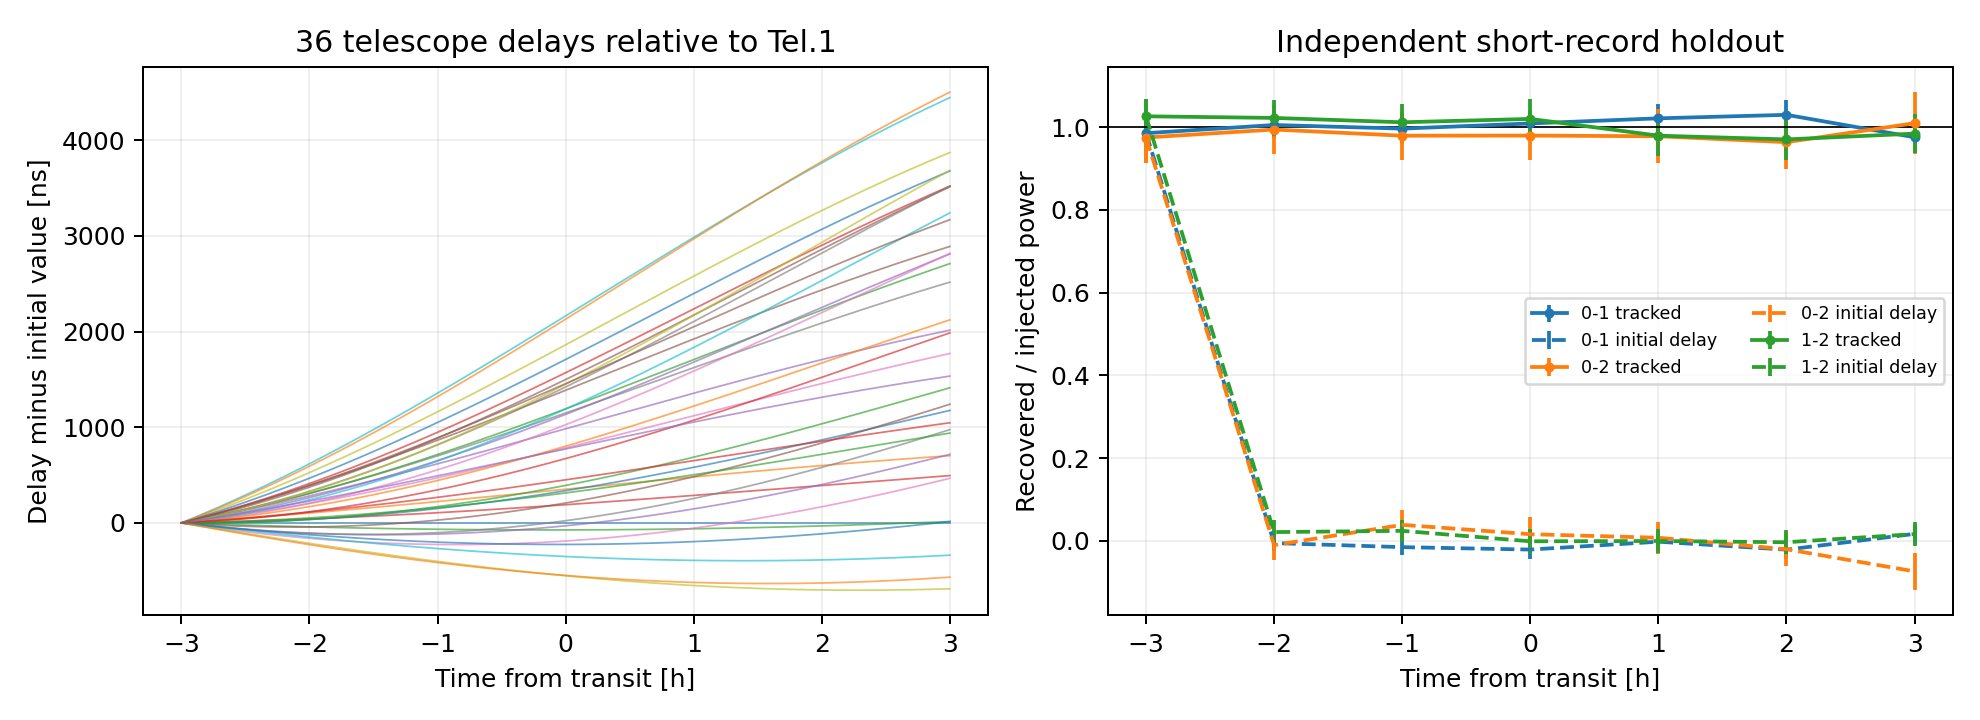

In [16]:
completed = subprocess.run([sys.executable, '-X', 'utf8', str(ROOT/'tools/validate_sii_tracking.py')],
                           cwd=ROOT, capture_output=True, text=True, encoding='utf-8')
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)
completed.check_returncode()
TRACKING = ROOT/'validation/sii_tracking'
tracking_summary = json.loads((TRACKING/'summary.json').read_text(encoding='utf-8'))
assert all(item['passed'] for item in tracking_summary['checks'])
summary['tracking_observation'] = {
    'execution': 'fresh sparse epoch waveforms executed by this notebook',
    'summary_sha256_lf': hashlib.sha256((TRACKING/'summary.json').read_bytes().replace(b'\r\n',b'\n')).hexdigest(),
    'actual_raw_records': tracking_summary['actual_raw_records'],
    'actual_raw_duration_s': tracking_summary['actual_raw_duration_s'],
    'checks': tracking_summary['checks']}
display(pd.DataFrame(tracking_summary['checks']))
display(pd.read_csv(TRACKING/'response.csv'))
display(Image(filename=str(TRACKING/'tracking_validation.png')))

### E. 圆盘源的七时刻追踪

下面由0.16 mas均匀圆盘及36台实际位置构造逐波长复相干矩阵，
以同一HBT光谱权重平均模平方，得到随自转变化的功率，再注入Tel.1/2/6共享波形。
响应使用同星等、同仪器、同时延状态的独立未分辨点源训练；不读取待测圆盘真值来求增益。
图中直接显示平方可见度和误差，零点附近不除以真值。

这仍是七个时刻的短波形处理检验，人工放大相关信号；并非真实恒星观测或连续整夜ADC。
逐波长矩阵保留合法复相干关系，但当前弱对生成器仍只模拟二阶统计。


追踪时刻 1/7：独立响应/零信号检查 True
追踪时刻 2/7：独立响应/零信号检查 True
追踪时刻 3/7：独立响应/零信号检查 True
追踪时刻 4/7：独立响应/零信号检查 True
追踪时刻 5/7：独立响应/零信号检查 True
追踪时刻 6/7：独立响应/零信号检查 True
追踪时刻 7/7：独立响应/零信号检查 True



,epoch,max_response_abs_z,max_null_abs_z,passed
0,0,1.287095,0.929549,True
1,1,0.462832,1.869497,True
2,2,3.275501,1.296647,True
3,3,0.322934,1.802475,True
4,4,1.189445,0.659742,True
5,5,1.404112,1.708342,True
6,6,0.719056,1.444822,True


,epoch,elapsed_s,baseline,truth,calibration_truth,gain,gain_sem,tracked_power,tracked_total_sem,initial_delay_power,initial_delay_holdout_sem,initial_delay_total_sem,null_mean,null_sem
0,0,-10800.0,0-1,0.884137,1.0,0.954832,0.006617,0.873109,0.008568,0.873109,0.005990,0.008514,-11.909354,55.228475
1,0,-10800.0,0-2,0.063682,1.0,0.983757,0.007064,0.062813,0.004533,0.062813,0.004510,0.004532,48.147813,55.749083
2,0,-10800.0,1-2,0.235109,1.0,0.986916,0.006659,0.235464,0.005746,0.235464,0.005523,0.005747,-49.401773,53.145942
3,1,-7200.0,0-1,0.838640,1.0,0.990088,0.006852,0.841454,0.008685,-0.001078,0.005002,0.005002,-54.652905,49.012768
4,1,-7200.0,0-2,0.008704,1.0,1.009281,0.008299,0.009772,0.004790,-0.004221,0.004913,0.004913,91.778996,49.092872
5,1,-7200.0,1-2,0.120781,1.0,0.978120,0.007762,0.118189,0.005602,-0.004322,0.004720,0.004720,90.597140,49.622210
6,2,-3600.0,0-1,0.806686,1.0,0.984574,0.006696,0.811047,0.007870,-0.002490,0.004888,0.004888,70.235637,54.167137
7,2,-3600.0,0-2,0.000017,1.0,0.985565,0.006779,-0.000229,0.004654,0.000923,0.004960,0.004960,-58.484954,47.906717
8,2,-3600.0,1-2,0.063487,1.0,0.986912,0.007249,0.076838,0.004076,0.002164,0.004809,0.004809,-26.243255,49.114073
9,3,0.0,0-1,0.795391,1.0,0.951201,0.006755,0.793799,0.008604,0.004893,0.005067,0.005067,-89.017841,49.386449


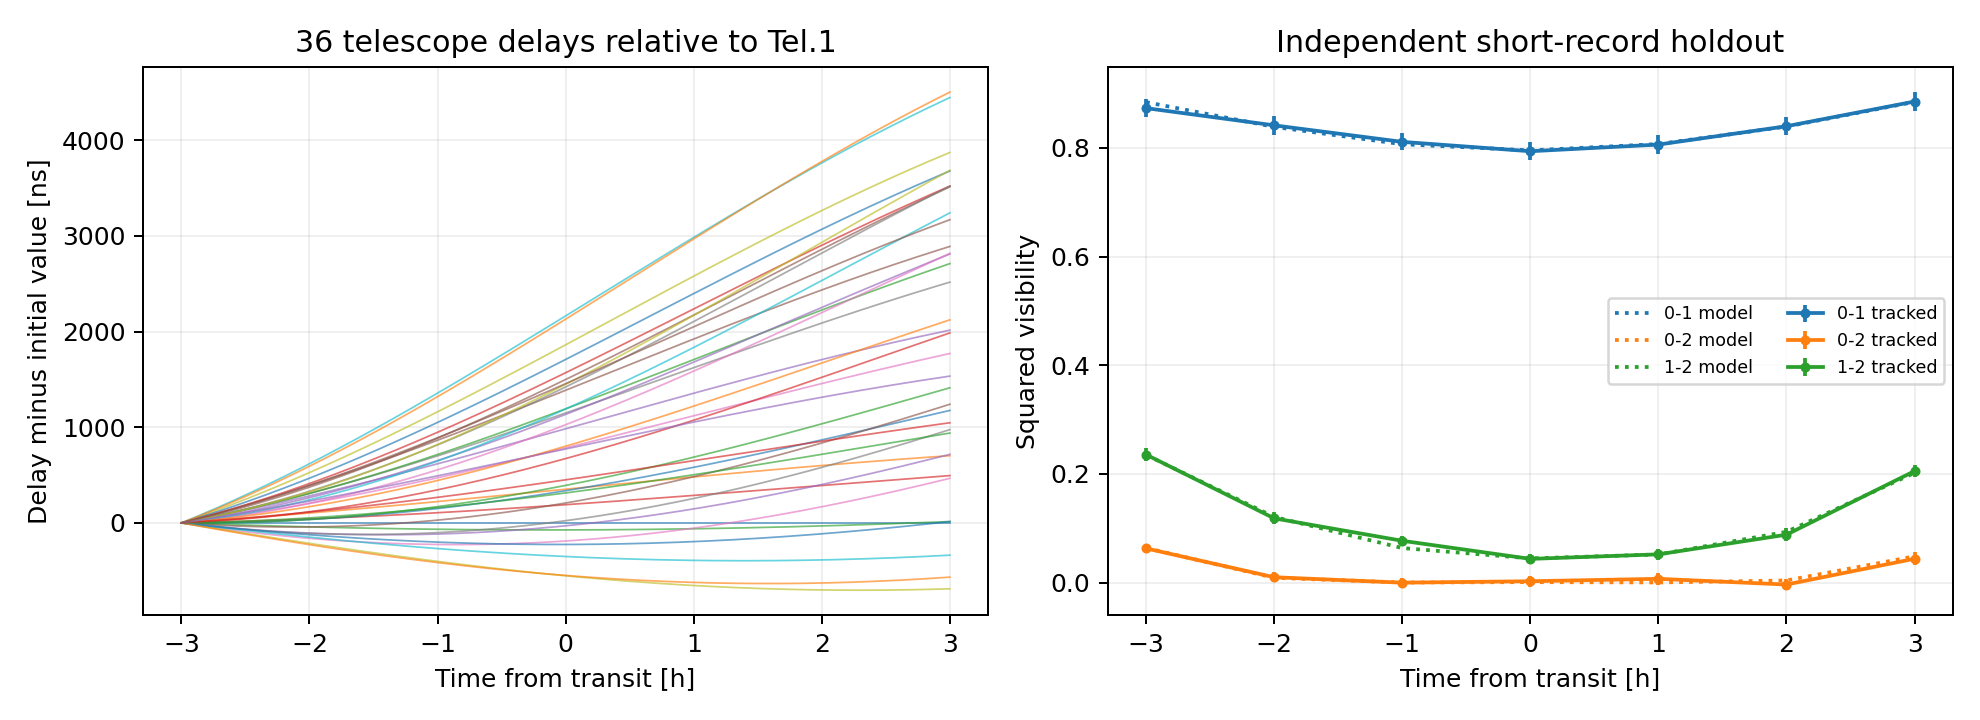

In [17]:
completed = subprocess.run([sys.executable, '-X', 'utf8', str(ROOT/'tools/validate_sii_tracking.py'),
                           '--source-case', 'single_disk', '--seed', '20260908'],
                           cwd=ROOT, capture_output=True, text=True, encoding='utf-8')
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)
completed.check_returncode()
SOURCE_OBS = ROOT/'validation/sii_source_tracking'
source_summary = json.loads((SOURCE_OBS/'summary.json').read_text(encoding='utf-8'))
summary['source_observation'] = {
    'execution': 'fresh sparse epoch waveforms executed by this notebook',
    'summary_sha256_lf': hashlib.sha256((SOURCE_OBS/'summary.json').read_bytes().replace(b'\r\n',b'\n')).hexdigest(),
    'actual_raw_records': source_summary['actual_raw_records'],
    'checks': source_summary['checks']}
display(pd.DataFrame(source_summary['checks']))
display(pd.read_csv(SOURCE_OBS/'response.csv'))
display(Image(filename=str(SOURCE_OBS/'tracking_validation.png')))

### F. 探索性图像的数值与重复稳定性

改变图像网格与UV合并尺度，再重复随机测量。这里仍沿用第8节图像估计器，
不会将第9节的误差验证自动套在这些图像上。


In [18]:
convergence_rows=[]
for size,cell in [(24,120.),(40,120.),(32,60.)]:
    case='binary';uv=sii.prepare_reconstruction_uv(pipelines[case].measurements,cell_mlambda=cell)
    kernel=reco.power_sampling_kernel(uv,size,FOV)
    fit=reco.reconstruct_uv_data(uv,grid_size=size,fov_mas=FOV,support_radius_mas=.32,
        starts=3,max_iter=8000,smoothness=fits[case].metrics['smoothness'],seed=SEED+500,_power_kernel=kernel)
    truth=truth_image(case,source_cases[case],fit.theta_mas)
    _,metrics=reco._best_truth_alignment(fit.image,truth)
    convergence_rows.append({'grid':size,'cell_Mlambda':cell,'constraints':len(uv.u_lambda),
        'converged':fit.metrics['optimizer_success'],'truth_nrmse':metrics['truth_nrmse'],
        'truth_correlation':metrics['truth_correlation'],'power_rmse':fit.metrics['fit_rmse']})
convergence_table=pd.DataFrame(convergence_rows)
convergence_table.to_csv(OUT/'convergence.csv',index=False)
summary['convergence']=convergence_table.to_dict(orient='records')
display(convergence_table)

,grid,cell_Mlambda,constraints,converged,truth_nrmse,truth_correlation,power_rmse
0,24,120.0,1448,True,0.495611,0.902441,0.042990
1,40,120.0,1448,True,0.423966,0.916268,0.042716
2,32,60.0,4185,True,0.539020,0.873114,0.060189


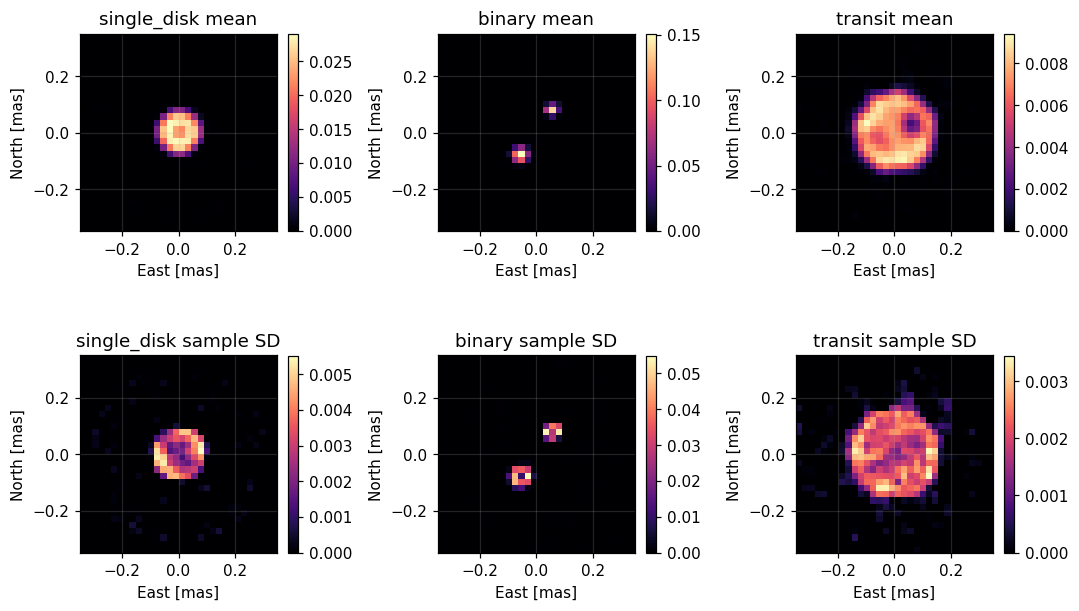

,source,nrmse_mean,nrmse_std,converged_fraction
0,binary,0.552780,0.081456,1.0
1,single_disk,0.204786,0.048294,1.0
2,transit,0.395106,0.028960,1.0


In [19]:
repeat_rows=[]; ensembles={}; REPEATS=12
for source_index,case in enumerate(['single_disk','binary','transit']):
    uv=uv_data[case];kernel=kernels[case]
    reference=pipelines[case].measurements.copy()
    # 用同一加权分组规则形成理论期望，只用于生成检验样本。
    reference['visibility2_measured']=reference.visibility2_true
    model=sii.prepare_reconstruction_uv(reference,cell_mlambda=120.).visibility_abs2
    images=[]
    for repeat in range(REPEATS):
        rng=np.random.default_rng(SEED+1000+100*source_index+repeat)
        gain=1+rng.normal(0.,uv.calibration_relative_sigma)
        trial=replace(uv,visibility_abs2=gain*model+rng.normal(0.,uv.sigma))
        fit=reco.reconstruct_uv_data(trial,grid_size=GRID,fov_mas=FOV,support_radius_mas=.32,
            starts=2,max_iter=8000,smoothness=fits[case].metrics['smoothness'],
            seed=SEED+2000+repeat,_power_kernel=kernel)
        aligned,metrics=reco._best_truth_alignment(fit.image,truths[case]);images.append(aligned)
        repeat_rows.append({'source':case,'repeat':repeat,'converged':fit.metrics['optimizer_success'],
            'stationarity_passed':fit.metrics['stationarity_passed'],
            'nrmse':metrics['truth_nrmse'],'truth_correlation':metrics['truth_correlation'],
            'retained_flux':metrics['truth_alignment_retained_flux']})
    ensembles[case]=np.asarray(images)
repeat_table=pd.DataFrame(repeat_rows);repeat_table.to_csv(OUT/'image_repeats.csv',index=False)
summary['image_repeats']=repeat_table.groupby('source').agg(
    nrmse_mean=('nrmse','mean'),nrmse_std=('nrmse','std'),converged_fraction=('converged','mean')).reset_index().to_dict(orient='records')
fig,axes=plt.subplots(2,3,figsize=(10,6))
for column,(case,images) in enumerate(ensembles.items()):
    for row,image in enumerate([images.mean(axis=0),images.std(axis=0,ddof=1)]):
        im=axes[row,column].imshow(image,origin='lower',extent=[-.35,.35,-.35,.35],cmap='magma')
        axes[row,column].set(title=case+(' mean' if row==0 else ' sample SD'),xlabel='East [mas]',ylabel='North [mas]')
        fig.colorbar(im,ax=axes[row,column],fraction=.045)
fig.tight_layout();fig.savefig(FIG/'06_image_stability.png');plt.show()
display(pd.DataFrame(summary['image_repeats']))

## 保存本次执行证据

基准记录、相关曲线、UV测量和新增教学图都由上述单元生成；附加实验有独立的种子和适用范围。
完整推导见物理说明。结果是条件性模拟，原始光追缓存的再生成和真实观测夜晚不在本次复现范围内。


In [20]:
summary['scope']={'source':'static scenes, observed total AB magnitude',
    'optical_passband':'2 nm top-hat scenario over main response curves',
    'source_transmission_scale':.7836336,'source_transmission_origin':'scenario assumption, not measured electronics',
    'weak_thermal_approximation':'pair generator omits thermal self noise; degeneracy is reported',
    'reconstruction_repeats':REPEATS,'pixel_intervals':'not confidence intervals',
    'calibration':'shared gain profiled, independent statistical sigma retained',
    'joint_observation':'section 9 connects full-array short records to diameter sufficient statistics; image reconstruction retains the earlier estimator',
    'notebook_execution':'all cells executed in this run'}
(OUT/'summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2)+'\n',encoding='utf-8')
print('科学验证结果已写入：',OUT/'summary.json')
display(pd.DataFrame(summary['reconstruction']))

科学验证结果已写入： E:\LACT_pylast2\sii_gls_review_20260905\validation\sii_science\summary.json


,source,constraints,converged,chi2_per_point,gain,gain_sigma,smoothness,stationarity_gap,stationarity_passed,iterations,training_all_converged
0,binary,1448,True,0.918088,1.015132,0.001642,0.0001,0.025374,True,1725,True
1,single_disk,1448,True,1.071930,1.016379,0.002267,0.0100,0.014688,True,472,True
2,ellipse,1448,True,0.977754,1.018196,0.002409,0.0100,0.027592,True,669,True
3,transit,1448,True,0.943680,1.004056,0.004012,0.0100,0.016613,True,779,True
